In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #daf1a1; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #002762">Stability of the P1-iso-P1 Method</h3>
</div>

Imports:

In [11]:
from scipy.sparse.linalg import (
    splu,
    eigs,
    eigsh,
    LinearOperator
)
import matplotlib.pyplot as plt
import numpy as np

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *

---

<div style="background-color: #f1e2a1; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #002762">Ladyzhenskaya–Babuška–Brezzi (LBB) Condition:</h3>
</div>

The LBB (inf-sup) condition is a necessary and sufficient stability criteria for saddle-point problems (like the Stokes equations) to ensure a unique, stable solution.

### 1. Continuous Definition
Velocity space $V$ and pressure space $Q$ must satisfy:
$$\exists \beta>0: \quad \inf_{q \in Q \setminus \{0\}} \space \sup_{v \in V \setminus \{0\}} \left(\frac{\int_{\Omega}q(\nabla \cdot v)d\Omega}{\|v\|_{V}\cdot\|q\|_{Q}}\right) \ge \beta$$

### 2. Discrete Algebraic System
Mapping continuous fields to nodal vectors ($\mathbf{u} \in \mathbb{R}^{2N_v}$, $\mathbf{p} \in \mathbb{R}^{N_p}$) yields the discrete inf-sup framework:

$$\exists \beta>0: \quad \inf_{\mathbf{p} \not= \mathbf{0}} \space \sup_{\mathbf{u} \not= \mathbf{0}} \left(\frac{\mathbf{p}^T \mathbf{B} \mathbf{u}}{\left(\mathbf{u}^T \mathbf{M}_v \mathbf{u}\right)^{1/2} \cdot \left(\mathbf{p}^T \mathbf{M}_p \mathbf{p}\right)^{1/2}}\right) \ge \beta$$

Where:
* **$\mathbf{B} = [\mathbf{B}_x \quad \mathbf{B}_y]$**: Discrete divergence matrix coupling pressure and velocity.
* **$\mathbf{M}_v = \begin{bmatrix} \mathbf{A} & \mathbf{0} \\ \mathbf{0} & \mathbf{A} \end{bmatrix}$**: Velocity energy weight matrix ($\mathbf{A}$ is the discrete Laplacian).
* **$\mathbf{M}_p$**: Pressure mass matrix accounting for spatial overlap of pressure basis functions.

### 3. Practical Stability Test (Generalized Eigenvalue Problem)
Maximizing over $\mathbf{u}$ and minimizing over $\mathbf{p}$ via the Rayleigh quotient transforms the condition into a straightforward matrix eigenvalue problem:

$$\exists \beta>0: \quad \sqrt{\lambda_{min}\left(\mathbf{M}_p^{-1}\left( \mathbf{B}_x \mathbf{A}^{-1} \mathbf{B}_x^T + \mathbf{B}_y \mathbf{A}^{-1} \mathbf{B}_y^T \right)\right)} \ge \beta$$

#### Grid Verification Rules:
* **Stable Grid Combinations:** As the mesh size $h \to 0$, the minimum eigenvalue $\lambda_{\min}$ bounds away from zero ($\lambda_{\min} \ge \beta^2 > 0$).
* **Unstable Grid Combinations:** As the mesh size $h \to 0$, $\lambda_{\min} \to 0$, indicating spurious pressure oscillations (checkerboard patterns).


---

Loading Data & Taking Look at the Mesh:

In [3]:
data = np.load('Meshes/LBB_test_mesh_data.npz')
p_raw = data['p']
tri_idx = data['t_raw']
data.close()

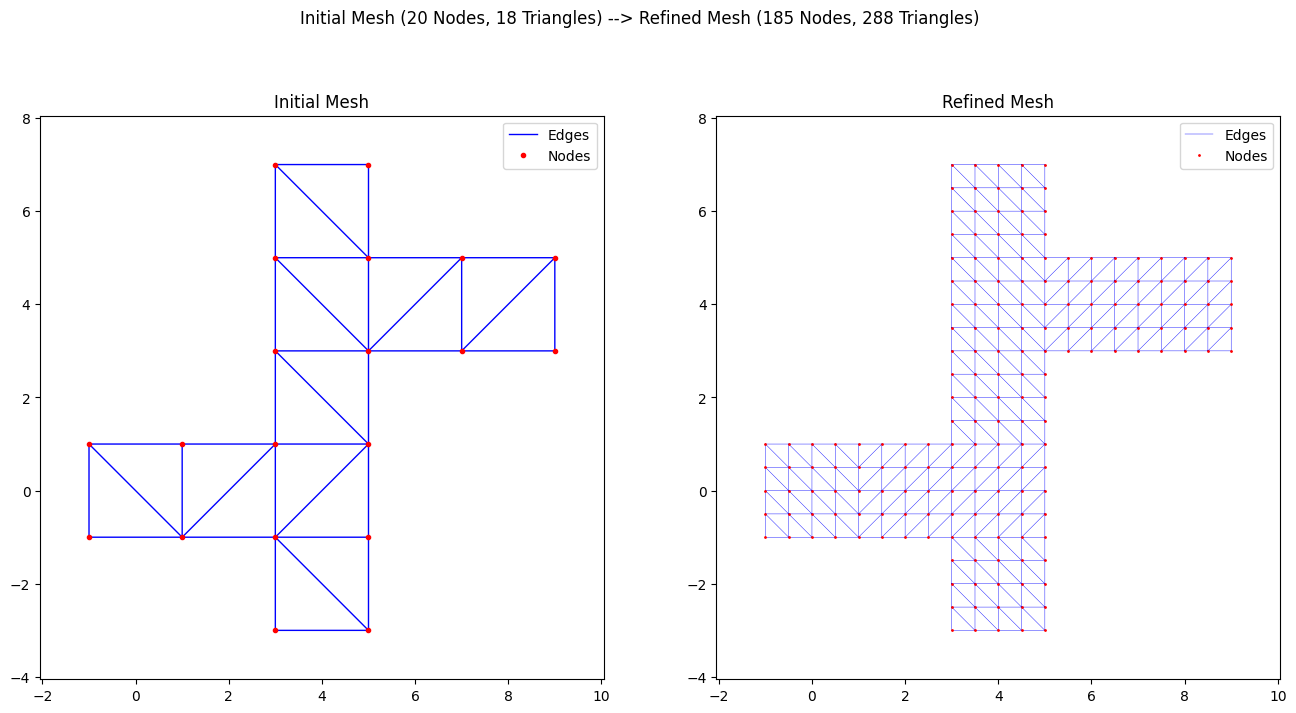

In [4]:
_ = Plot_Initial_Refined_meshes('Meshes/LBB_test_mesh_data.npz', num_of_refinements=2)

Calculating    $\quad \mathbf{M}_p^{-1}, \quad \mathbf{A}^{-1}, \quad \mathbf{B}_x, \quad \mathbf{B}_y$:

In [ ]:
# p_original, e_original, t_original = build_stable_mesh(p_raw, tri_idx)

# matrices = {
#     'mass_matrix_inv':[],
#     'pressure_matrix_x':[],
#     'pressure_matrix_y':[],
#     'stiffness_matrix_inv':[]
# }

# print('_'*70)
# for i in range(0,5):
#     p_coarse, e_coarse, t_coarse = refine_n_times(p_original, e_original, t_original, 
#                                                   number_of_refinements=i)
#     p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

#     print(f'''
#     Iteration {i}:\n
#           Coarse Grid shapes: p: {p_coarse.shape}\n
#                               e: {e_coarse.shape}\n
#                               t: {t_coarse.shape}\n
#           Fine Grid shapes:   p: {p_fine.shape}\n
#                               e: {e_fine.shape}\n
#                               t: {t_fine.shape}\n''')
    
#     M_p = calculate_mass_M(p_coarse, t_coarse)
#     M_p_inv = inv(M_p)
    
#     B_x, B_y = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    
#     A = calculate_velocity_A(p_fine, t_fine, 1)
#     A_inv = inv(A)

#     print(f'''
#           Matrix shapes: M:  {M_p.shape}\n
#                          Bx: {B_x.shape}\n
#                          By: {B_y.shape}\n
#                          A:  {A.shape}\n
#            ''')
#     print('_'*70)

#     matrices['mass_matrix_inv'].append(M_p_inv)
#     matrices['pressure_matrix_x'].append(B_x)
#     matrices['pressure_matrix_y'].append(B_y)
#     matrices['stiffness_matrix_inv'].append(A_inv)

Finding $\lambda_i$:

$$
\lambda_{min}\left(\mathbf{M}_p^{-1}\left( \mathbf{B}_x \mathbf{A}^{-1} \mathbf{B}_x^T + \mathbf{B}_y \mathbf{A}^{-1} \mathbf{B}_y^T \right)\right) \ge \beta^2 > 0
$$

In [ ]:
# min_eigenvalues = []

# for M_inv, B_x, B_y, A_inv in zip(
#                                   matrices['mass_matrix_inv'],
#                                   matrices['pressure_matrix_x'],
#                                   matrices['pressure_matrix_y'],
#                                   matrices['stiffness_matrix_inv']
#                                   ):
#     K_hat = M_inv @ (B_x @ A_inv @ B_x.T + B_y @ A_inv @ B_y.T)
#     eigenvalues, _ = eigs(K_hat, k=2, which='SM')
#     print(f'Eigenvalues: {eigenvalues}')
#     lambda_min = np.min(eigenvalues)
#     min_eigenvalues.append(lambda_min)

---